# Portfolio Project: Visualization in Python - Canada Immigration Analytics

---

# 04 — Geospatial Visualization of Canadian Immigration Origins

## Purpose

This notebook is the geospatial conclusion of the Canada Immigration Visualization project.

This notebook focuses on one analytical objective:

> **How is immigration to Canada distributed geographically across the world, and how does that spatial pattern change over time?**

The notebook uses the cleaned immigration dataset created in Notebook 01 and a world-country boundary file to build interactive Folium maps.

### Analytical questions

1. How complete is the linkage between the immigration dataset and the geographic boundary file?
2. Which parts of the world contributed the largest cumulative immigration flows to Canada from 1980–2013?
3. What did the geographic pattern look like in 2013 specifically?
4. Which countries increased or decreased their share of Canadian immigration between 1980 and 2013?
5. What are the limitations of country-level choropleth mapping for this dataset?


## 1. Data and geographic boundary sources

### Immigration data

The analytical data come from the cleaned output of Notebook 01, derived from the United Nations dataset:

*United Nations, Department of Economic and Social Affairs, Population Division (2015). International Migration Flows to and from Selected Countries: The 2015 Revision.*

The dataset contains annual immigration flows to Canada by citizenship/origin classification from 1980 through 2013.

### Geographic boundary data

The notebook uses a local **Natural Earth low-resolution world boundary file** exported to GeoJSON format.

The boundary layer provides:

- country names;
- ISO-3 identifiers;
- continent labels; and
- country polygon geometries.

Natural Earth is a public-domain geographic dataset widely used for small-scale world mapping.

### Why a linkage audit is necessary

The immigration dataset and the boundary file were created independently and therefore do not always use identical country names. For example:

- `Russian Federation` vs. `Russia`;
- `Republic of Korea` vs. `South Korea`;
- `Viet Nam` vs. `Vietnam`;
- `United Republic of Tanzania` vs. `Tanzania`.

Small island states and special administrative regions may also be absent from a low-resolution world boundary file.

Rather than silently dropping those cases, this notebook explicitly harmonizes names and reports the resulting map coverage before any choropleth is created.


In [1]:
from pathlib import Path
import json

import numpy as np
import pandas as pd
import geopandas as gpd
import folium
from branca.colormap import LinearColormap
from IPython.display import display

DATA_CANDIDATES = [
    Path("data") / "canada_immigration_clean.csv",
    Path("canada_immigration_clean.csv"),
]

GEO_CANDIDATES = [
    Path("data") / "world_countries.geojson",
    Path("world_countries.geojson"),
]

DATA_PATH = next((p for p in DATA_CANDIDATES if p.exists()), None)
GEO_PATH = next((p for p in GEO_CANDIDATES if p.exists()), None)

if DATA_PATH is None:
    raise FileNotFoundError(
        "Cleaned immigration data not found. Run Notebook 01 first."
    )

if GEO_PATH is None:
    raise FileNotFoundError(
        "world_countries.geojson not found. Place it in the notebook directory "
        "or in a data/ subdirectory."
    )

df = pd.read_csv(DATA_PATH)
world = gpd.read_file(GEO_PATH)

years = [str(year) for year in range(1980, 2014)]

print(f"Immigration data: {DATA_PATH}")
print(f"Boundary data:    {GEO_PATH}")
print(f"Immigration origins: {len(df)}")
print(f"Boundary polygons:   {len(world)}")

display(world[["name", "iso_a3", "continent"]].head())


Immigration data: data/canada_immigration_clean.csv
Boundary data:    world_countries.geojson
Immigration origins: 194
Boundary polygons:   177


,name,iso_a3,continent
0,Fiji,FJI,Oceania
1,Tanzania,TZA,Africa
2,W. Sahara,ESH,Africa
3,Canada,CAN,North America
4,United States of America,USA,North America


## 2. Harmonize country names and audit geographic coverage

A small alias dictionary aligns naming conventions between the UN immigration table and the Natural Earth boundary layer.

The goal is not to alter the substantive immigration data. The aliases only create a separate `MapName` key used for geographic matching.


In [2]:
NAME_ALIASES = {
    "Bolivia (Plurinational State of)": "Bolivia",
    "Bosnia and Herzegovina": "Bosnia and Herz.",
    "Brunei Darussalam": "Brunei",
    "Central African Republic": "Central African Rep.",
    "Czech Republic": "Czechia",
    "Democratic People's Republic of Korea": "North Korea",
    "Democratic Republic of the Congo": "Dem. Rep. Congo",
    "Dominican Republic": "Dominican Rep.",
    "Equatorial Guinea": "Eq. Guinea",
    "Iran (Islamic Republic of)": "Iran",
    "Lao People's Democratic Republic": "Laos",
    "Republic of Korea": "South Korea",
    "Republic of Moldova": "Moldova",
    "Russian Federation": "Russia",
    "State of Palestine": "Palestine",
    "Swaziland": "eSwatini",
    "Syrian Arab Republic": "Syria",
    "The former Yugoslav Republic of Macedonia": "Macedonia",
    "United Kingdom of Great Britain and Northern Ireland": "United Kingdom",
    "United Republic of Tanzania": "Tanzania",
    "Venezuela (Bolivarian Republic of)": "Venezuela",
    "Viet Nam": "Vietnam",
    "Western Sahara": "W. Sahara",
}

df_map = df.copy()
df_map["MapName"] = df_map["Country"].replace(NAME_ALIASES)

boundary_names = set(world["name"])
df_map["Mapped"] = df_map["MapName"].isin(boundary_names)

mapped_count = int(df_map["Mapped"].sum())
unmapped_count = int((~df_map["Mapped"]).sum())

mapped_total = df_map.loc[df_map["Mapped"], "Total"].sum()
all_total = df_map["Total"].sum()
weighted_coverage = mapped_total / all_total * 100

coverage_summary = pd.DataFrame(
    {
        "Metric": [
            "Immigration origins",
            "Mapped origins",
            "Unmapped origins",
            "Origin-count coverage",
            "Immigration-volume coverage",
        ],
        "Value": [
            len(df_map),
            mapped_count,
            unmapped_count,
            f"{mapped_count / len(df_map) * 100:.1f}%",
            f"{weighted_coverage:.2f}%",
        ],
    }
)

display(coverage_summary)


,Metric,Value
0,Immigration origins,194
1,Mapped origins,164
2,Unmapped origins,30
3,Origin-count coverage,84.5%
4,Immigration-volume coverage,98.77%


In [3]:
unmapped = (
    df_map.loc[~df_map["Mapped"], ["Country", "Total"]]
    .sort_values("Total", ascending=False)
    .reset_index(drop=True)
)

display(unmapped)


,Country,Total
0,Mauritius,15690
1,Singapore,14579
2,Saint Vincent and the Grenadines,9707
3,"China, Hong Kong Special Administrative Region",9327
4,Grenada,9091
5,Barbados,6923
6,Saint Lucia,4802
7,Dominica,2470
8,Malta,1546
9,Seychelles,1266


### Interpretation of the linkage audit

The low-resolution world boundary layer does not contain every small island state, microstate, or special administrative region represented in the immigration table.

However, geographic coverage should be evaluated in two ways:

- **record coverage** — the proportion of origin categories that can be mapped;
- **immigration-volume coverage** — the proportion of cumulative immigration represented by mapped origins.

The second measure is especially important for this project because several unmapped cases are very small in cumulative volume. The choropleths therefore represent nearly all immigration volume even though not every origin record has a polygon.

This limitation is documented rather than hidden.


## 3. Prepare an interactive geographic layer

To support richer Folium tooltips, the immigration measures are joined to the geographic boundary table.

The joined geographic dataset contains:

- cumulative immigration (`Total`);
- 1980 immigration;
- 2013 immigration;
- each country's share of the Canadian total in 1980 and 2013; and
- change in immigration share between those two years.


In [4]:
annual_1980_total = df_map["1980"].sum()
annual_2013_total = df_map["2013"].sum()

df_map["Share_1980"] = df_map["1980"] / annual_1980_total * 100
df_map["Share_2013"] = df_map["2013"] / annual_2013_total * 100
df_map["Share_Change_pp"] = df_map["Share_2013"] - df_map["Share_1980"]

map_attributes = df_map[
    [
        "Country",
        "MapName",
        "Continent",
        "Region",
        "Development_Group",
        "1980",
        "2013",
        "Total",
        "Share_1980",
        "Share_2013",
        "Share_Change_pp",
    ]
].copy()

world_data = world.merge(
    map_attributes,
    left_on="name",
    right_on="MapName",
    how="left",
)

print(
    f"Boundary polygons linked to immigration records: "
    f"{world_data['Country'].notna().sum()} of {len(world_data)}"
)


Boundary polygons linked to immigration records: 164 of 177


## 4. Where did immigrants to Canada originate over the full 1980–2013 period?

A choropleth is appropriate because the analytical variable is attached to geographic areas and the objective is to show the **global spatial distribution** of cumulative immigration.

The map is interactive:

- hover over countries to inspect values;
- zoom and pan to explore regions;
- use the legend to interpret the sequential scale.

The map encodes cumulative counts, so darker/higher-intensity areas represent larger total immigration flows to Canada over the full observation period.


In [5]:
world_map_total = folium.Map(
    location=[20, 0],
    zoom_start=2,
    tiles="CartoDB positron",
)

folium.Choropleth(
    geo_data=json.loads(world_data.to_json()),
    data=world_data.dropna(subset=["Total"]),
    columns=["name", "Total"],
    key_on="feature.properties.name",
    fill_color="YlOrRd",
    fill_opacity=0.75,
    line_opacity=0.25,
    nan_fill_color="lightgray",
    legend_name="Total immigrants to Canada, 1980–2013",
    name="Cumulative immigration",
).add_to(world_map_total)

tooltip_fields = [
    "name", "Country", "Continent", "Region",
    "Total", "1980", "2013"
]
tooltip_aliases = [
    "Map country:",
    "UN origin label:",
    "Continent:",
    "Region:",
    "Total 1980–2013:",
    "Immigrants in 1980:",
    "Immigrants in 2013:",
]

folium.GeoJson(
    json.loads(world_data.to_json()),
    name="Country details",
    style_function=lambda feature: {
        "fillColor": "transparent",
        "color": "transparent",
        "weight": 0,
        "fillOpacity": 0,
    },
    tooltip=folium.GeoJsonTooltip(
        fields=tooltip_fields,
        aliases=tooltip_aliases,
        localize=True,
        sticky=False,
    ),
).add_to(world_map_total)

folium.LayerControl(collapsed=True).add_to(world_map_total)

world_map_total


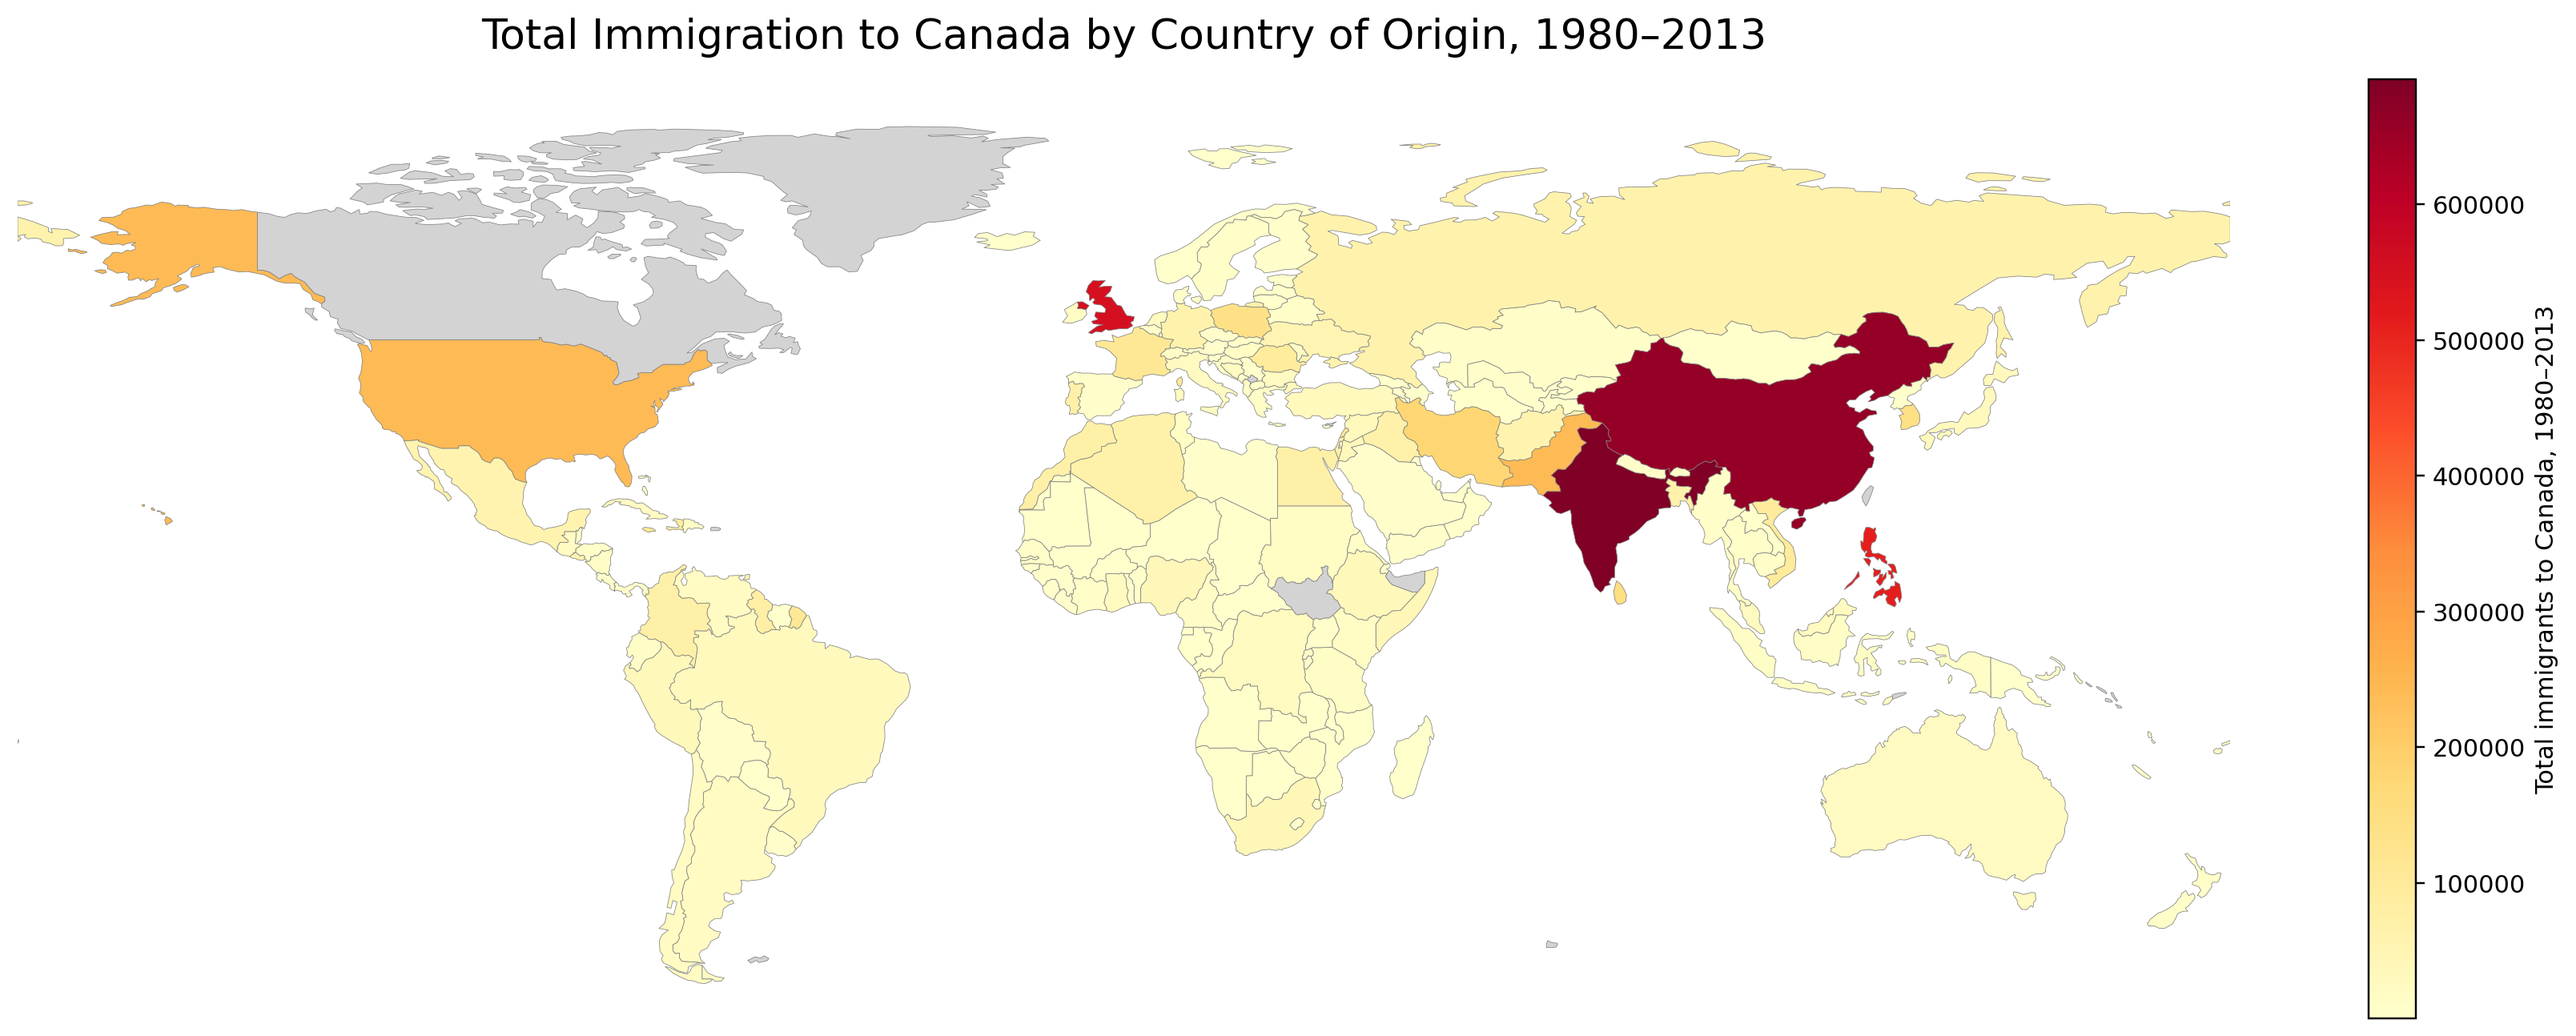

### Interpretation

The cumulative map reinforces the country-ranking analysis from Notebook 02 but adds geographic structure.

The largest source countries are not distributed randomly across the globe. High-volume origins are concentrated especially in **Asia**, while substantial cumulative contributions are also visible from parts of **Europe**, North America, and selected countries in other regions.

The geospatial representation is useful because neighboring countries and regional clusters can be perceived immediately—something a ranked bar chart cannot show.


## 5. What did the geographic pattern look like in 2013?

The cumulative map blends together 34 years of immigration history.  
A second choropleth isolates **2013**, allowing the spatial pattern at the end of the dataset to be compared with the long-run picture.

This map uses the same geographic boundaries and interaction design but encodes only the 2013 annual count.


In [6]:
world_map_2013 = folium.Map(
    location=[20, 0],
    zoom_start=2,
    tiles="CartoDB positron",
)

folium.Choropleth(
    geo_data=json.loads(world_data.to_json()),
    data=world_data.dropna(subset=["2013"]),
    columns=["name", "2013"],
    key_on="feature.properties.name",
    fill_color="YlGnBu",
    fill_opacity=0.75,
    line_opacity=0.25,
    nan_fill_color="lightgray",
    legend_name="Immigrants to Canada in 2013",
    name="2013 immigration",
).add_to(world_map_2013)

folium.GeoJson(
    json.loads(world_data.to_json()),
    name="Country details",
    style_function=lambda feature: {
        "fillColor": "transparent",
        "color": "transparent",
        "weight": 0,
        "fillOpacity": 0,
    },
    tooltip=folium.GeoJsonTooltip(
        fields=["name", "Country", "2013", "Share_2013"],
        aliases=[
            "Map country:",
            "UN origin label:",
            "Immigrants in 2013:",
            "Share of 2013 total (%):",
        ],
        localize=True,
        sticky=False,
    ),
).add_to(world_map_2013)

folium.LayerControl(collapsed=True).add_to(world_map_2013)

world_map_2013


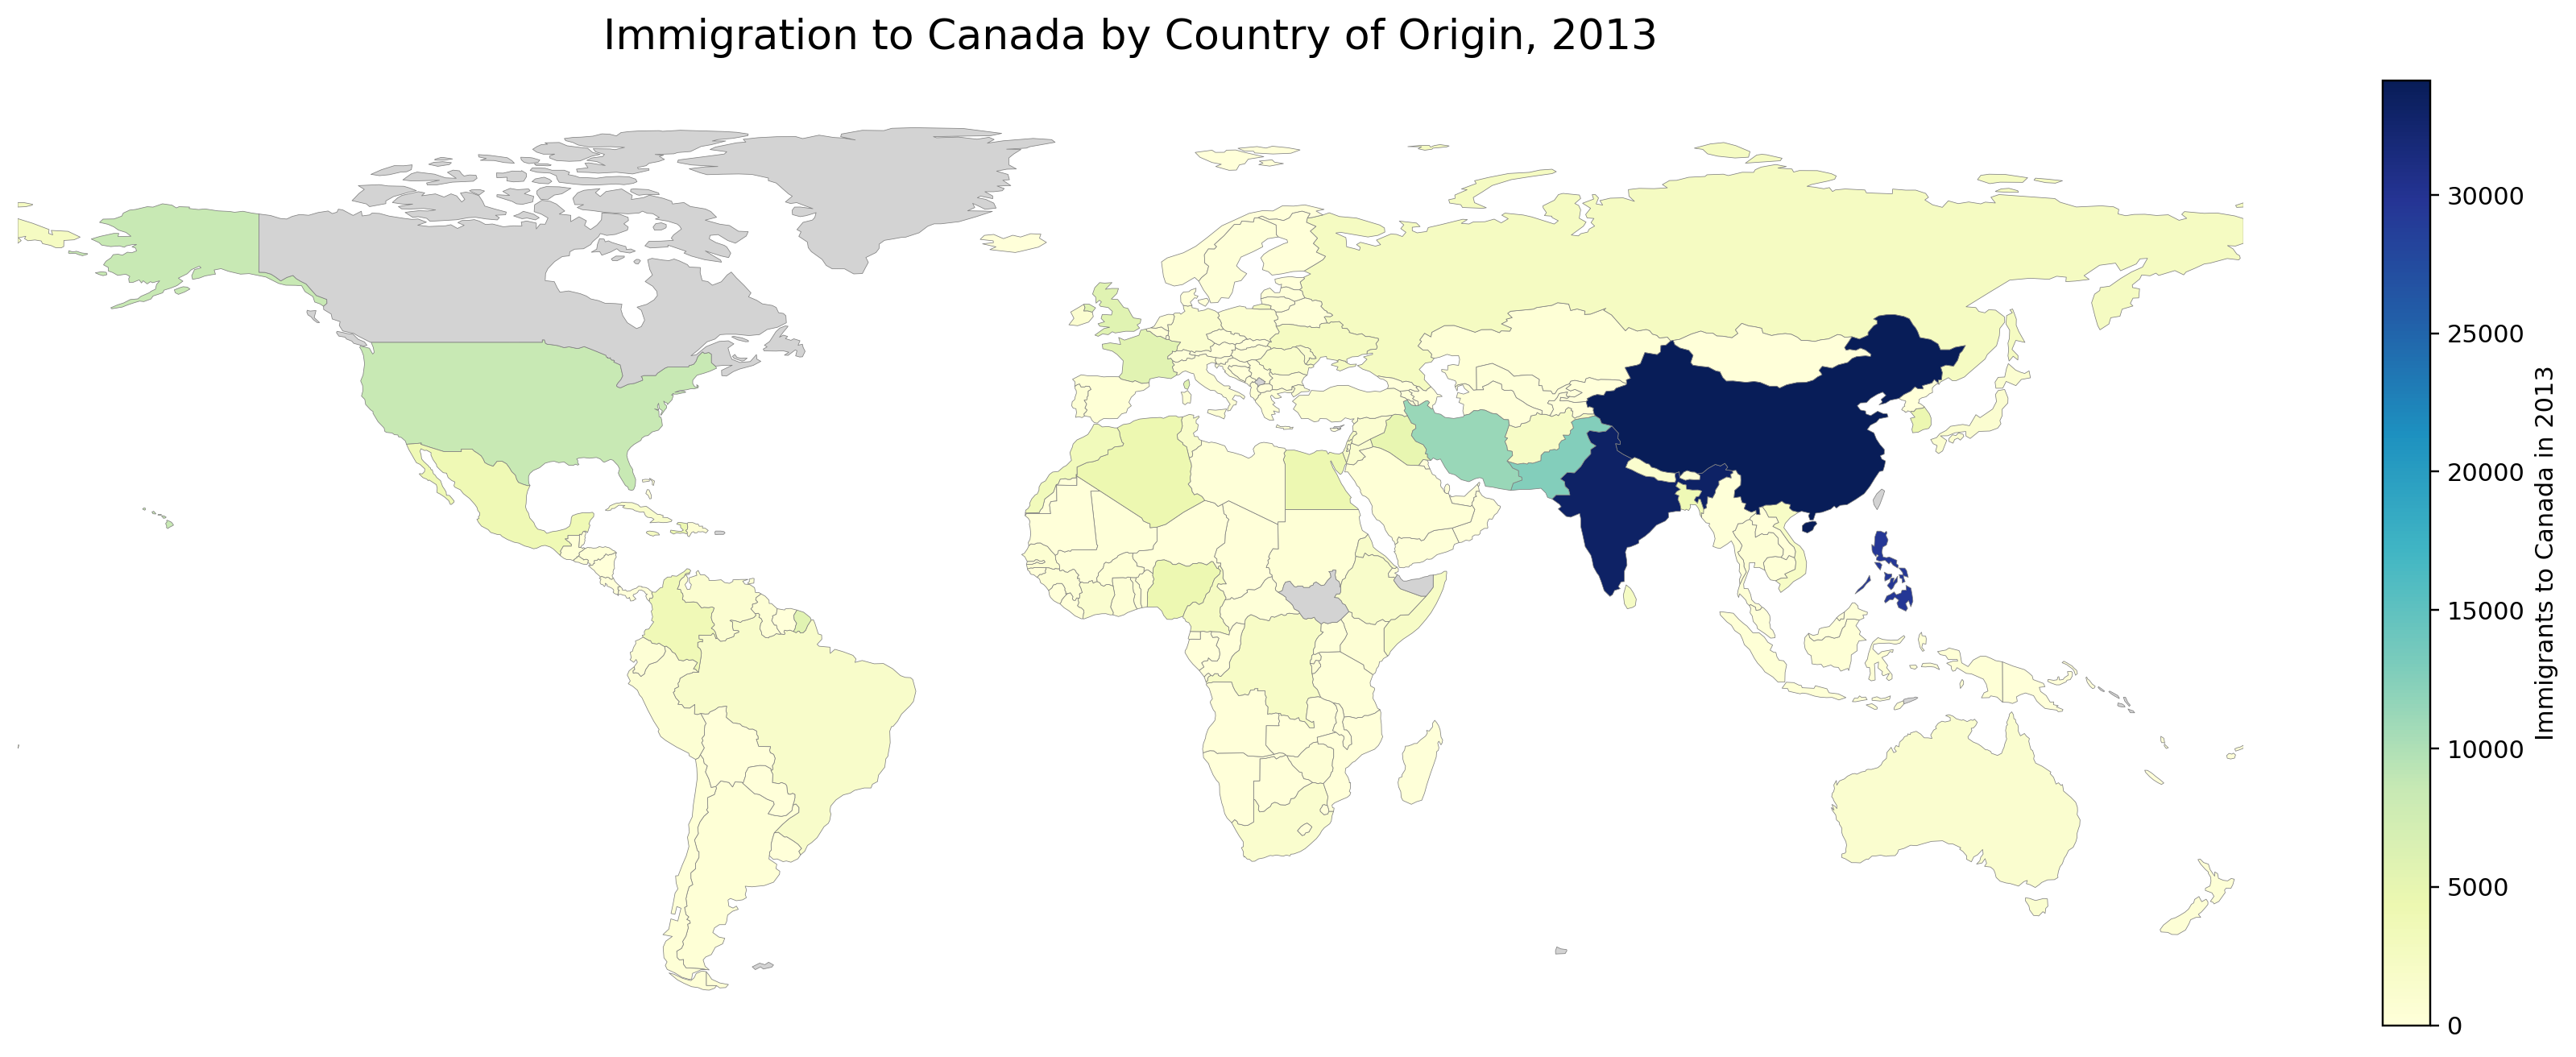

### Interpretation

The 2013 map makes the shift toward Asian source countries more visually prominent than the cumulative map.

This is consistent with the temporal and compositional analyses in Notebooks 02 and 03: the geography of Canadian immigration changed over time, so the dominant countries in the long-run total are not necessarily identical to the strongest origins at the end of the observation period.


## 6. Which countries gained or lost immigration share between 1980 and 2013?

Absolute counts can rise simply because total immigration rises. To examine **structural geographic change**, the final map compares each country's share of all identified international immigration in 1980 with its share in 2013.

The mapped variable is measured in **percentage points**:

Share Change = Share_2013 - Share_1980

Positive values indicate that an origin became more important in Canada's immigration mix; negative values indicate a declining share.

A diverging scale is appropriate because the variable has a meaningful zero point.


In [7]:
change_values = world_data["Share_Change_pp"].dropna()
change_bound = float(
    max(abs(change_values.quantile(0.02)), abs(change_values.quantile(0.98)))
)

change_cmap = LinearColormap(
    ["#8c2d04", "#f7f7f7", "#084081"],
    vmin=-change_bound,
    vmax=change_bound,
    caption="Change in share of Canadian immigration, 1980–2013 (percentage points)",
)

def change_style(feature):
    value = feature["properties"].get("Share_Change_pp")
    if value is None:
        return {
            "fillColor": "#d9d9d9",
            "color": "#777777",
            "weight": 0.4,
            "fillOpacity": 0.4,
        }

    return {
        "fillColor": change_cmap(value),
        "color": "#666666",
        "weight": 0.4,
        "fillOpacity": 0.75,
    }

world_map_change = folium.Map(
    location=[20, 0],
    zoom_start=2,
    tiles="CartoDB positron",
)

folium.GeoJson(
    json.loads(world_data.to_json()),
    style_function=change_style,
    tooltip=folium.GeoJsonTooltip(
        fields=[
            "name", "Country",
            "Share_1980", "Share_2013", "Share_Change_pp"
        ],
        aliases=[
            "Map country:",
            "UN origin label:",
            "Share in 1980 (%):",
            "Share in 2013 (%):",
            "Change (percentage points):",
        ],
        localize=True,
        sticky=False,
    ),
    name="Change in immigration share",
).add_to(world_map_change)

change_cmap.add_to(world_map_change)

world_map_change


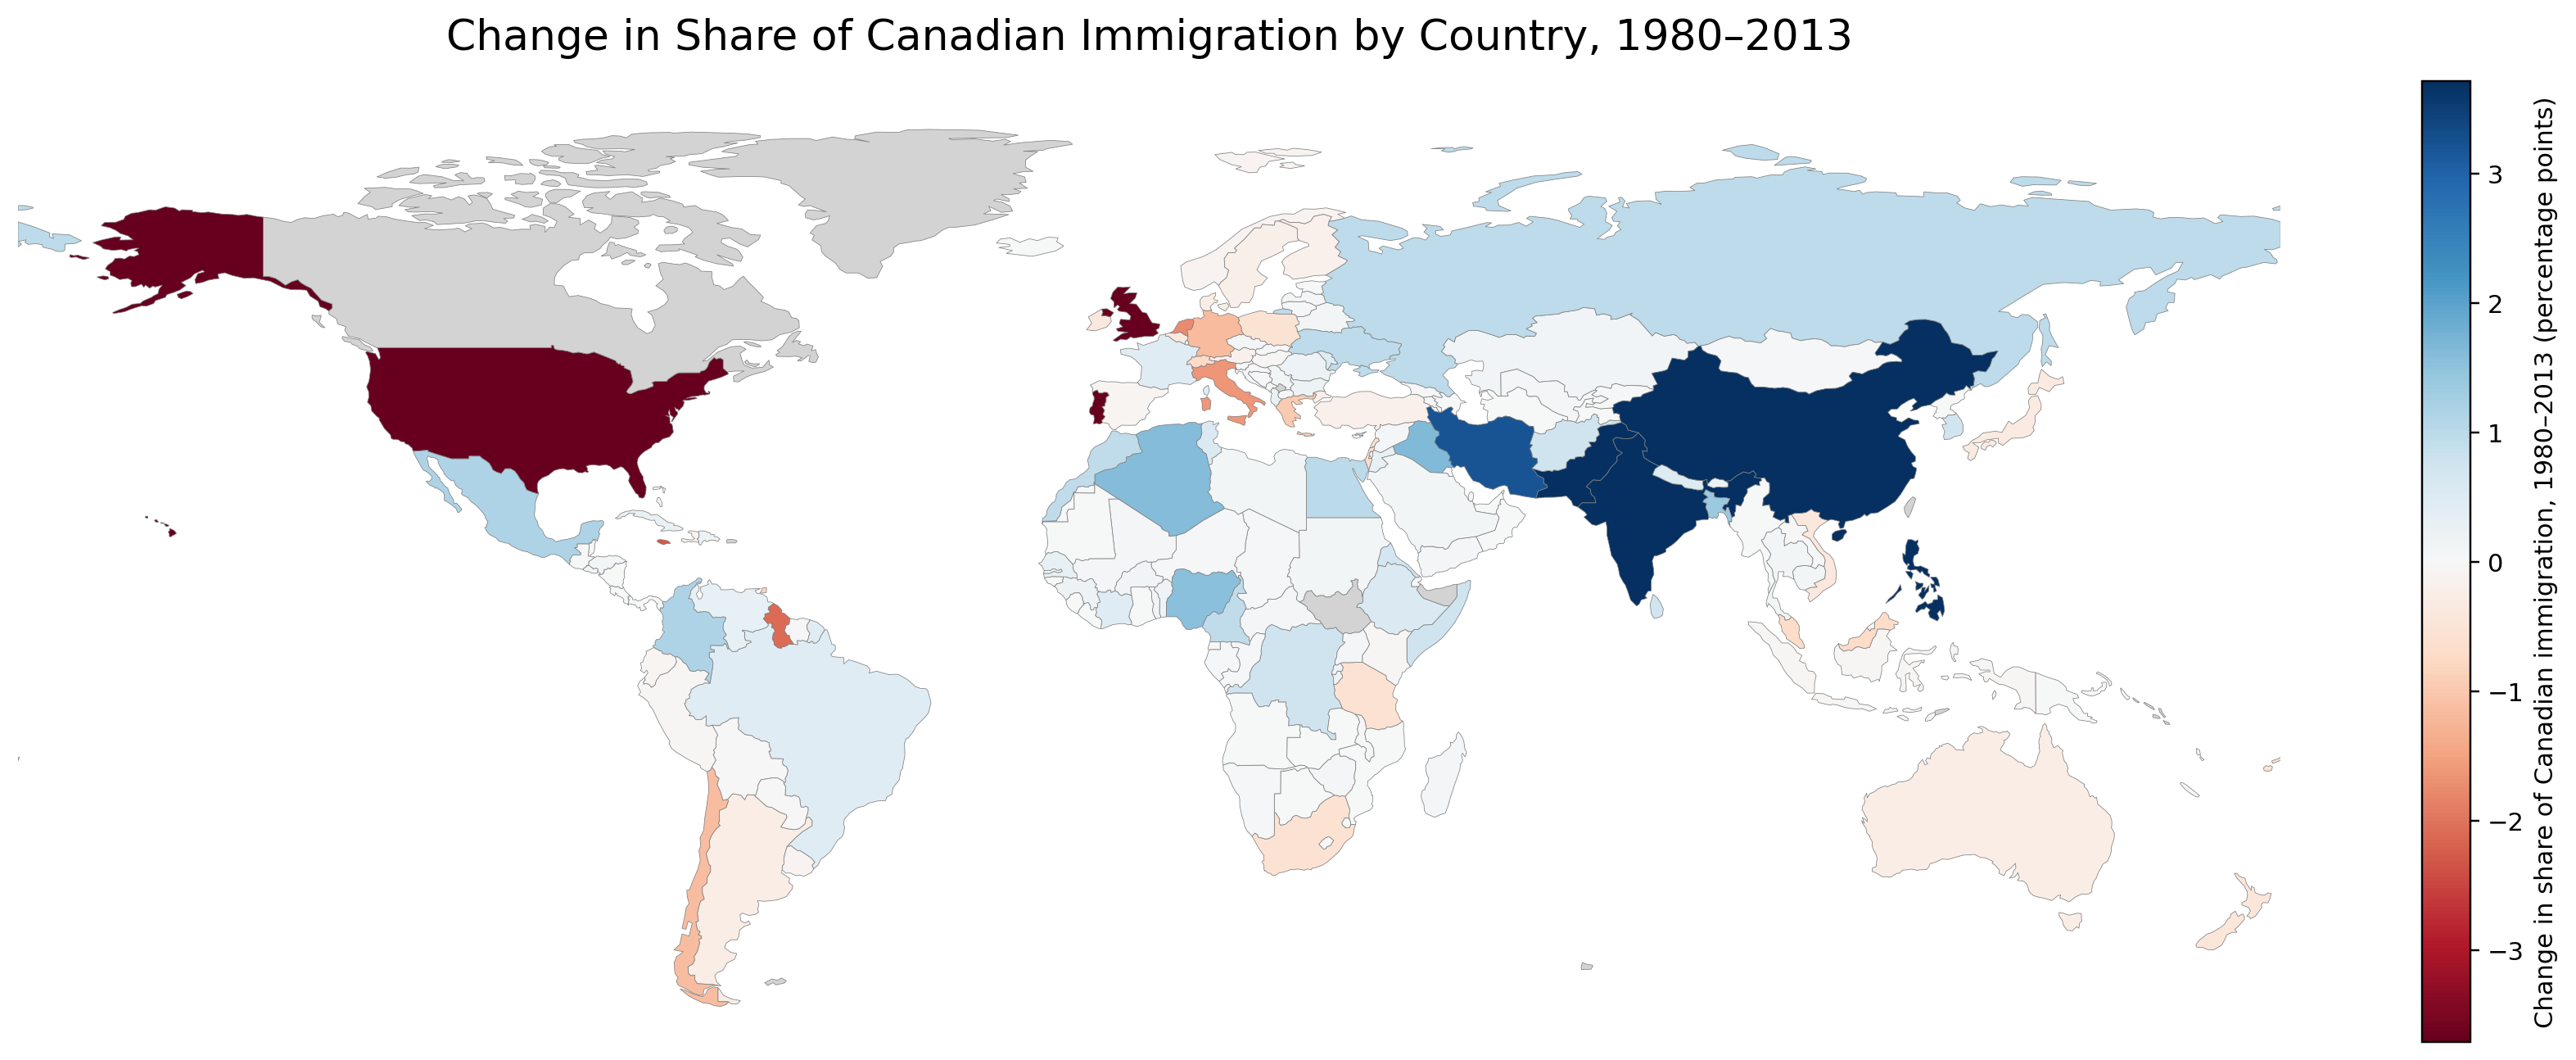

In [8]:
largest_gains = (
    df_map[df_map["Mapped"]]
    [["Country", "Share_1980", "Share_2013", "Share_Change_pp"]]
    .sort_values("Share_Change_pp", ascending=False)
    .head(10)
)

largest_declines = (
    df_map[df_map["Mapped"]]
    [["Country", "Share_1980", "Share_2013", "Share_Change_pp"]]
    .sort_values("Share_Change_pp", ascending=True)
    .head(10)
)

print("Largest gains in immigration share:")
display(largest_gains.round(2))

print("Largest declines in immigration share:")
display(largest_declines.round(2))


Largest gains in immigration share:


,Country,Share_1980,Share_2013,Share_Change_pp
35,China,5.17,13.25,8.08
135,Philippines,6.10,11.47,5.37
129,Pakistan,0.99,4.89,3.91
78,India,8.96,12.85,3.89
80,Iran (Islamic Republic of),1.18,4.38,3.20
81,Iraq,0.26,1.91,1.65
2,Algeria,0.08,1.68,1.60
126,Nigeria,0.08,1.62,1.54
14,Bangladesh,0.08,1.47,1.39
38,Colombia,0.27,1.41,1.14


Largest declines in immigration share:


,Country,Share_1980,Share_2013,Share_Change_pp
182,United Kingdom of Great Britain and Northern I...,22.24,2.26,-19.97
184,United States of America,9.46,3.30,-6.16
137,Portugal,4.51,0.24,-4.27
85,Jamaica,3.23,0.96,-2.26
73,Guyana,2.35,0.25,-2.10
121,Netherlands,1.91,0.15,-1.75
84,Italy,1.84,0.21,-1.62
66,Germany,1.64,0.47,-1.17
34,Chile,1.24,0.11,-1.14
68,Greece,1.07,0.12,-0.96


### Interpretation

The change map distinguishes **growth in absolute volume** from **growth in relative importance**.

Countries with positive values increased their share of Canada's identified international immigration between 1980 and 2013, while negative values lost share. This makes long-run geographic restructuring visible in a way that raw cumulative counts cannot.

The map should be interpreted together with the country-level tables because choropleths emphasize spatial pattern, whereas the tables provide precise ranking and magnitude.


## 7. Export interactive maps

Folium maps are HTML-based. Saving them as standalone files makes it possible to open the interactive maps directly in a browser.


In [9]:
OUTPUT_DIR = Path("maps")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

map_files = {
    "cumulative": OUTPUT_DIR / "canada_immigration_total_1980_2013.html",
    "2013": OUTPUT_DIR / "canada_immigration_2013.html",
    "change": OUTPUT_DIR / "canada_immigration_share_change_1980_2013.html",
}

world_map_total.save(map_files["cumulative"])
world_map_2013.save(map_files["2013"])
world_map_change.save(map_files["change"])

for label, path in map_files.items():
    print(f"{label:>10}: {path}")


cumulative: maps/canada_immigration_total_1980_2013.html
      2013: maps/canada_immigration_2013.html
    change: maps/canada_immigration_share_change_1980_2013.html


## 8. Geospatial findings

The maps extend the earlier visual analysis in several ways:

1. **Immigration origins are geographically clustered rather than spatially uniform.** Major contributions are concentrated in particular countries and regions.
2. **Asia is central to the long-run geography of Canadian immigration.** This spatial pattern is consistent with the country rankings and continental composition analysis.
3. **The 2013 geography differs from the cumulative 1980–2013 picture.** A time-specific map reveals the later shift in source-country importance.
4. **Relative-share mapping exposes structural change.** Some countries became substantially more important in Canada's immigration mix, while others lost share.
5. **Geospatial linkage is not perfect.** Small islands, microstates, and some special administrative regions are absent from the low-resolution boundary layer, although mapped countries account for nearly all cumulative immigration volume.

These results are descriptive. A choropleth shows where immigration origins are located and how their relative importance differs, but it does not explain the political, economic, demographic, or policy mechanisms behind those patterns.


## 9. Map-design and methodological limitations

### Choropleth limitations

Country polygons vary dramatically in physical area. A geographically large country can dominate visual attention even when its immigration count is modest, while small but important source countries may be visually understated.

For that reason, these maps should be interpreted together with the ranked and statistical visualizations from Notebooks 02 and 03.

### Boundary-resolution limitations

The Natural Earth low-resolution layer intentionally simplifies small geographic features. Some island states, microstates, and special administrative regions in the immigration dataset therefore do not have independent polygons.

### Country-name harmonization

Cross-dataset geographic analysis often requires name reconciliation. The alias dictionary used here is intentionally transparent and limited to known naming differences. It does not merge substantive immigration categories into different countries.

### Temporal interpretation

The cumulative map aggregates 34 years and therefore hides temporal change. The 2013 and share-change maps are included specifically to reduce that limitation.

---

## Project visualization workflow

The four notebooks now form a coherent progression:

**01 — Data Preparation**  
Raw UN workbook → validated analytical dataset

**02 — Exploratory Visual Analytics**  
Trends → rankings → distributions → concentration → variability

**03 — Advanced Statistical Visualization**  
Distributional comparison → normalization → heatmaps → association

**04 — Geospatial Visualization**  
Geographic linkage → cumulative choropleth → 2013 pattern → spatial change

Together, the project demonstrates Python-based visual analytics across conventional, statistical, and interactive geospatial visualization.
